In [39]:
import pandas as pd

In [40]:
df=pd.read_csv('pd_speech_features.csv')

In [41]:
df

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,250,0,0.80903,0.56355,0.28385,417,416,0.004627,0.000052,0.00064,...,3.0706,3.0190,3.1212,2.4921,3.5844,3.5400,3.3805,3.2003,6.8671,0
752,250,0,0.16084,0.56499,0.59194,415,413,0.004550,0.000220,0.00143,...,1.9704,1.7451,1.8277,2.4976,5.2981,4.2616,6.3042,10.9058,28.4170,0
753,251,0,0.88389,0.72335,0.46815,381,380,0.005069,0.000103,0.00076,...,51.5607,44.4641,26.1586,6.3076,2.8601,2.5361,3.5377,3.3545,5.0424,0
754,251,0,0.83782,0.74890,0.49823,340,339,0.005679,0.000055,0.00092,...,19.1607,12.8312,8.9434,2.2044,1.9496,1.9664,2.6801,2.8332,3.7131,0


In [42]:
df = df.drop(columns=['id'])

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 754 entries, gender to class
dtypes: float64(749), int64(5)
memory usage: 4.3 MB


In [44]:
total_nulls = df.isnull().sum().sum()
print(total_nulls)

0


In [45]:
import pandas as pd
from scipy.stats import shapiro

# Select numeric columns only
numeric_cols = df.select_dtypes(include='number').columns

normality_results = {}

for col in numeric_cols:
    stat, p = shapiro(df[col].dropna())
    if p > 0.05:
        normality_results[col] = 'Normal'
    else:
        normality_results[col] = 'Not Normal'

# Display results
for col, result in normality_results.items():
    print(f"{col}: {result}")


gender: Not Normal
PPE: Not Normal
DFA: Not Normal
RPDE: Not Normal
numPulses: Not Normal
numPeriodsPulses: Not Normal
meanPeriodPulses: Not Normal
stdDevPeriodPulses: Not Normal
locPctJitter: Not Normal
locAbsJitter: Not Normal
rapJitter: Not Normal
ppq5Jitter: Not Normal
ddpJitter: Not Normal
locShimmer: Not Normal
locDbShimmer: Not Normal
apq3Shimmer: Not Normal
apq5Shimmer: Not Normal
apq11Shimmer: Not Normal
ddaShimmer: Not Normal
meanAutoCorrHarmonicity: Not Normal
meanNoiseToHarmHarmonicity: Not Normal
meanHarmToNoiseHarmonicity: Not Normal
minIntensity: Not Normal
maxIntensity: Not Normal
meanIntensity: Not Normal
f1: Normal
f2: Not Normal
f3: Not Normal
f4: Normal
b1: Not Normal
b2: Not Normal
b3: Not Normal
b4: Not Normal
GQ_prc5_95: Not Normal
GQ_std_cycle_open: Not Normal
GQ_std_cycle_closed: Not Normal
GNE_mean: Not Normal
GNE_std: Not Normal
GNE_SNR_TKEO: Not Normal
GNE_SNR_SEO: Not Normal
GNE_NSR_TKEO: Not Normal
GNE_NSR_SEO: Not Normal
VFER_mean: Not Normal
VFER_std: No

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [46]:
import pandas as pd


numeric_cols = df.select_dtypes(include='number').columns

outlier_counts = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = outliers.shape[0]

print("Outlier counts per numeric column:")
for col, count in outlier_counts.items():
    print(f"{col}: {count}")


Outlier counts per numeric column:
gender: 0
PPE: 108
DFA: 0
RPDE: 0
numPulses: 11
numPeriodsPulses: 10
meanPeriodPulses: 10
stdDevPeriodPulses: 135
locPctJitter: 71
locAbsJitter: 72
rapJitter: 71
ppq5Jitter: 61
ddpJitter: 72
locShimmer: 29
locDbShimmer: 26
apq3Shimmer: 28
apq5Shimmer: 32
apq11Shimmer: 21
ddaShimmer: 28
meanAutoCorrHarmonicity: 87
meanNoiseToHarmHarmonicity: 96
meanHarmToNoiseHarmonicity: 18
minIntensity: 38
maxIntensity: 39
meanIntensity: 35
f1: 5
f2: 9
f3: 30
f4: 1
b1: 53
b2: 75
b3: 98
b4: 72
GQ_prc5_95: 34
GQ_std_cycle_open: 32
GQ_std_cycle_closed: 85
GNE_mean: 35
GNE_std: 41
GNE_SNR_TKEO: 29
GNE_SNR_SEO: 25
GNE_NSR_TKEO: 24
GNE_NSR_SEO: 39
VFER_mean: 70
VFER_std: 65
VFER_entropy: 72
VFER_SNR_TKEO: 61
VFER_SNR_SEO: 62
VFER_NSR_TKEO: 3
VFER_NSR_SEO: 3
IMF_SNR_SEO: 92
IMF_SNR_TKEO: 51
IMF_SNR_entropy: 41
IMF_NSR_SEO: 6
IMF_NSR_TKEO: 59
IMF_NSR_entropy: 7
mean_Log_energy: 18
mean_MFCC_0th_coef: 23
mean_MFCC_1st_coef: 14
mean_MFCC_2nd_coef: 4
mean_MFCC_3rd_coef: 2
mean_

In [47]:
import pandas as pd
from scipy.stats.mstats import winsorize

# Select numeric columns
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    # Determine lower and upper limits using IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply Winsorization in-place
    df[col] = winsorize(df[col], limits=(
        (df[col] < lower_bound).mean(),
        (df[col] > upper_bound).mean()
    ))


In [48]:

unique_classes = df['class'].unique()
print(unique_classes)


class_counts = df['class'].value_counts()
print(class_counts)


[1 0]
class
1    564
0    192
Name: count, dtype: int64


In [49]:
import pandas as pd
from scipy.stats import f_oneway


numeric_cols = df.select_dtypes(include='number').columns
target_col = 'class'

insignificant_cols = []


for col in numeric_cols:
    groups = [df[col][df[target_col] == cls] for cls in df[target_col].unique()]
    stat, p = f_oneway(*groups)
    if p > 0.05:
        insignificant_cols.append(col)
    print(f"{col}: p-value = {p:.5f}, {'Significant' if p <= 0.05 else 'Not Significant'}")


df.drop(columns=insignificant_cols, inplace=True)

print("\nRemoved insignificant columns:", insignificant_cols)


gender: p-value = 0.00000, Significant
PPE: p-value = 0.00077, Significant
DFA: p-value = 0.00000, Significant
RPDE: p-value = 0.00000, Significant
numPulses: p-value = 0.00000, Significant
numPeriodsPulses: p-value = 0.00000, Significant
meanPeriodPulses: p-value = 0.00000, Significant
stdDevPeriodPulses: p-value = 0.00027, Significant
locPctJitter: p-value = 0.00000, Significant
locAbsJitter: p-value = 0.00000, Significant
rapJitter: p-value = 0.00000, Significant
ppq5Jitter: p-value = 0.00000, Significant
ddpJitter: p-value = 0.00000, Significant
locShimmer: p-value = 0.00000, Significant
locDbShimmer: p-value = 0.00000, Significant
apq3Shimmer: p-value = 0.00019, Significant
apq5Shimmer: p-value = 0.00001, Significant
apq11Shimmer: p-value = 0.00000, Significant
ddaShimmer: p-value = 0.00019, Significant
meanAutoCorrHarmonicity: p-value = 0.00000, Significant
meanNoiseToHarmHarmonicity: p-value = 0.00000, Significant
meanHarmToNoiseHarmonicity: p-value = 0.00000, Significant
minInt

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


In [50]:
df

,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,locAbsJitter,...,tqwt_kurtosisValue_dec_25,tqwt_kurtosisValue_dec_26,tqwt_kurtosisValue_dec_27,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,0.000018,...,2.0062,1.6058,1.5466,1.5620,2.6445,4.4625,2.6202,3.0004,18.9405,1
1,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,0.000016,...,2.0470,1.5772,1.5530,1.5589,3.6107,9.5082,6.5245,6.3431,45.1780,1
2,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,0.000015,...,3.0664,1.5921,1.5399,1.5643,2.3308,4.8066,2.9199,3.1495,4.7666,1
3,0,0.65734,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,0.000038,...,1.9120,1.8829,6.9761,3.7805,3.5664,4.6857,4.8460,6.2650,4.0603,1
4,0,0.65734,0.79782,0.53028,236,235,0.008162,0.000352,0.00483,0.000038,...,1.7577,1.8821,7.8832,6.1727,5.8416,11.6891,8.2103,5.0559,6.1164,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,0,0.80903,0.56355,0.28385,417,416,0.004627,0.000052,0.00064,0.000003,...,1.7601,5.0509,3.4394,3.0706,3.0190,3.5400,3.3805,3.2003,6.8671,0
752,0,0.65734,0.56499,0.59194,415,413,0.004550,0.000220,0.00143,0.000006,...,3.0664,5.0509,19.6733,1.9704,1.7451,4.2616,6.3042,10.9058,28.4170,0
753,0,0.88389,0.72335,0.46815,381,380,0.005069,0.000103,0.00076,0.000004,...,1.6380,2.3279,27.3322,51.5607,44.4641,2.5361,3.5377,3.3545,5.0424,0
754,0,0.83782,0.74890,0.49823,340,339,0.005679,0.000055,0.00092,0.000005,...,1.5692,1.6052,5.4425,19.1607,12.8312,1.9664,2.6801,2.8332,3.7131,0


PCA AND KEEP ONLY TOP 80 COMPONENTS

In [54]:
import pandas as pd
from sklearn.decomposition import PCA

X = df.drop(columns=['class'])
y = df['class']

pca = PCA(n_components=80)
X_new = pca.fit_transform(X)


df_pca = pd.DataFrame(X_new, columns=[f'PC{i+1}' for i in range(80)])


df_pca['class'] = y




In [56]:
df_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC72,PC73,PC74,PC75,PC76,PC77,PC78,PC79,PC80,class
0,5.519009e+09,5.486549e+04,2.037231e+05,-1.191941e+05,-1.582008e+05,1.501471e+05,-4.620563e+05,3.561641e+04,-33042.866718,-497888.669081,...,-16.809486,-4.358571,53.216312,80.088365,-91.199363,23.154139,-8.198799,-84.718906,-1.439551,1
1,5.732592e+09,3.793188e+05,-2.454205e+04,-2.010036e+05,-7.958777e+04,1.623654e+05,-5.227538e+05,5.470661e+04,-17245.370803,-477724.023565,...,-14.948755,68.337019,-11.140720,-41.787053,-21.126287,46.116812,-50.956273,-142.585853,30.504195,1
2,5.862378e+09,-4.495651e+05,-5.045305e+04,-3.206656e+05,-1.198751e+05,2.029617e+05,-5.596778e+05,6.312114e+04,-39932.029443,-511103.491670,...,-1.381777,-12.706759,13.415015,-12.945943,-105.735729,-85.959779,-118.683232,-20.432796,-13.708985,1
3,6.900393e+09,-5.280345e+07,2.568669e+06,-7.869915e+06,-3.170328e+06,-1.212876e+06,-1.503759e+06,-2.954780e+04,145200.229276,527359.931398,...,-276.416951,-184.348101,-251.234079,-65.565211,-3.052609,-86.826831,-76.143060,-30.287711,106.607121,1
4,6.126637e+09,-8.026397e+07,-9.291903e+06,-1.259348e+07,-1.290248e+06,1.775203e+05,6.723876e+05,2.913368e+06,684621.364129,459275.578932,...,8.246115,268.466442,-295.308140,82.774510,20.155693,-92.268153,-0.857039,37.593139,37.407268,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,-4.399958e+09,-7.195936e+06,7.713415e+05,2.037888e+06,-2.125035e+03,1.717684e+05,4.330070e+05,1.302822e+05,-110244.685301,62327.965206,...,-1.288612,-79.474007,-156.229174,39.189716,-81.659655,-63.785752,146.715642,-26.281093,-57.259579,0
752,-2.794656e+09,-2.571190e+07,3.840123e+06,-1.084131e+06,1.659824e+06,6.149299e+05,1.042395e+06,5.123093e+05,357502.297328,266462.656239,...,-519.686412,572.371630,0.145227,124.517231,-78.768349,-36.630925,11.315663,15.775302,-155.692065,0
753,-2.516509e+09,8.127132e+06,5.951416e+05,1.649818e+06,-3.909101e+05,-4.519438e+05,2.128771e+05,-4.318834e+05,31771.289544,322728.712625,...,-19.793375,80.700744,104.249302,45.570672,-160.504166,49.287954,-43.772423,69.856248,-8.752866,0
754,4.689422e+08,1.376441e+06,1.540262e+06,1.848604e+06,-1.152266e+05,-5.261391e+04,3.929987e+05,-9.769353e+04,47380.366354,60956.626806,...,13.959597,-54.193860,-111.338066,319.054674,49.993670,107.508931,-9.764203,-78.657886,46.773222,0


In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split


X = df_pca.drop(columns=['class'])
y = df_pca['class']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)


Train set shape: (604, 81)
Test set shape: (152, 81)


In [58]:

unique_classes = train_df['class'].unique()
print("Unique classes:", unique_classes)

# Count of each class
class_counts = train_df['class'].value_counts()
print("\nClass distribution in train set:")
print(class_counts)


Unique classes: [1 0]

Class distribution in train set:
class
1    451
0    153
Name: count, dtype: int64


**GAN FOR DATA BALANCING**

In [59]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

# Separate features and target
X = train_df.drop('class', axis=1).values
y = train_df['class']

target_classes = y.unique()
desired_samples = 1000  # target per class

# Build GAN components
def build_generator():
    model = Sequential()
    model.add(Dense(128, activation='relu', input_dim=100))
    model.add(Dense(X.shape[1], activation='sigmoid'))
    return model

def build_discriminator():
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(X.shape[1],)))
    model.add(Dense(1, activation='sigmoid'))
    return model

def build_gan(generator, discriminator):
    discriminator.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])
    discriminator.trainable = False
    gan_input = Sequential()
    gan_input.add(generator)
    gan_input.add(discriminator)
    gan_input.compile(loss='binary_crossentropy', optimizer=Adam())
    return gan_input

# Initialize models
generator = build_generator()
discriminator = build_discriminator()
gan = build_gan(generator, discriminator)

# Train GAN
for epoch in range(500):
    idx = np.random.randint(0, X.shape[0], size=32)
    real_samples = X[idx]

    noise = np.random.normal(0, 1, size=(32, 100))
    fake_samples = generator.predict(noise, verbose=0)

    real_labels = np.ones((32, 1))
    fake_labels = np.zeros((32, 1))

    discriminator.train_on_batch(real_samples, real_labels)
    discriminator.train_on_batch(fake_samples, fake_labels)

    noise = np.random.normal(0, 1, size=(32, 100))
    gan_labels = np.ones((32, 1))
    gan.train_on_batch(noise, gan_labels)


synthetic_dfs = []

for cls in target_classes:
    cls_df = train_df[train_df['class'] == cls]
    num_to_generate = max(0, desired_samples - len(cls_df))

    if num_to_generate > 0:
        noise = np.random.normal(0, 1, size=(num_to_generate, 100))
        synthetic_samples = generator.predict(noise, verbose=0)
        synthetic_cls_df = pd.DataFrame(synthetic_samples, columns=train_df.drop('class', axis=1).columns)
        synthetic_cls_df['class'] = cls
        synthetic_dfs.append(synthetic_cls_df)


train_df = pd.concat([train_df] + synthetic_dfs, ignore_index=True)


train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check new distribution
print("Upsampled Training Set 'class' Distribution:")
print(train_df['class'].value_counts())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Upsampled Training Set 'class' Distribution:
class
0    1000
1    1000
Name: count, dtype: int64


In [60]:
pip install catboost

In [61]:
X_train = train_df.drop('class', axis=1)
y_train = train_df['class']
X_test = test_df.drop('class', axis=1)
y_test = test_df['class']


**grid search**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import itertools

models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

param_grids = {
    "RandomForest": {
        "n_estimators": [100, 200],
        "max_depth": [10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ['sqrt', 'log2']
    },
    "ExtraTrees": {
        "n_estimators": [100, 200],
        "max_depth": [10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ['sqrt', 'log2']
    },
    "DecisionTree": {
        "max_depth": [10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": [None, 'sqrt']
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6],
        "min_child_weight": [1, 5],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },
    "CatBoost": {
        "iterations": [500],
        "learning_rate": [0.01, 0.1],
        "depth": [6, 10],
        "l2_leaf_reg": [1, 3],
        "border_count": [32, 64]
    }
}

grid_search_results = {}

for model_name, model in models.items():
    param_combinations = list(itertools.product(*param_grids[model_name].values()))
    best_score = 0
    best_params = None

    for combo in param_combinations:
        params = dict(zip(param_grids[model_name].keys(), combo))

        # For CatBoost, re-initialize the model with the current parameters to avoid the set_params issue
        if model_name == "CatBoost":
            model = CatBoostClassifier(**params, verbose=0, random_state=42)

        model.set_params(**params)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = accuracy_score(y_test, y_pred)

        if score > best_score:
            best_score = score
            best_params = params

    grid_search_results[model_name] = best_params

for model_name, best_params in grid_search_results.items():
    print(f"Best parameters for {model_name}: {best_params}")


Best parameters for RandomForest: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best parameters for ExtraTrees: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best parameters for DecisionTree: {'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None}
Best parameters for XGBoost: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 1.0}
Best parameters for CatBoost: {'iterations': 500, 'learning_rate': 0.01, 'depth': 10, 'l2_leaf_reg': 1, 'border_count': 64}



==================== RandomForest ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       0.77      1.00      0.87      1000
           1       1.00      0.70      0.83      1000

    accuracy                           0.85      2000
   macro avg       0.89      0.85      0.85      2000
weighted avg       0.89      0.85      0.85      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.13      0.23        39
           1       0.77      1.00      0.87       113

    accuracy                           0.78       152
   macro avg       0.88      0.56      0.55       152
weighted avg       0.83      0.78      0.70       152

Training Time: 1.4845 sec
Inference Time: 0.022173 sec
Memory Usage (MB): 0.00
Cohen's Kappa: 0.1794
Brier Score: 0.1350
Confusion Matrix:
 [[  5  34]
 [  0 113]]


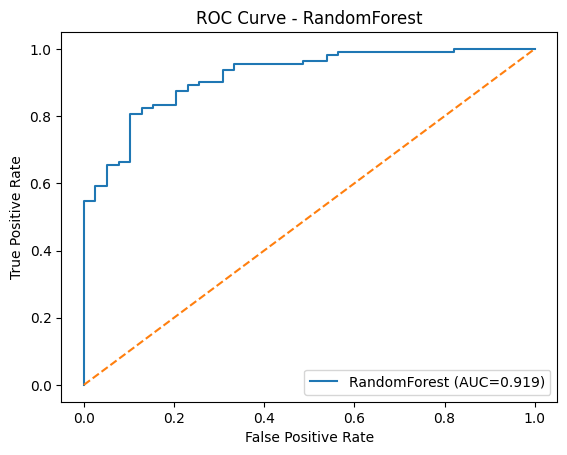

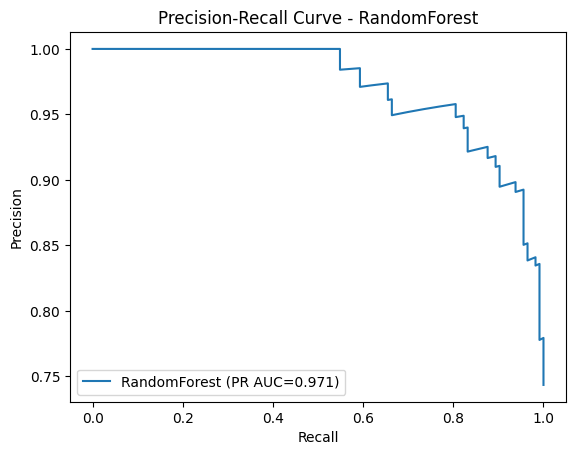


==================== ExtraTrees ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       0.65      1.00      0.79      1000
           1       1.00      0.47      0.64      1000

    accuracy                           0.74      2000
   macro avg       0.83      0.74      0.72      2000
weighted avg       0.83      0.74      0.72      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.10      0.19        39
           1       0.76      1.00      0.87       113

    accuracy                           0.77       152
   macro avg       0.88      0.55      0.53       152
weighted avg       0.82      0.77      0.69       152

Training Time: 0.3211 sec
Inference Time: 0.024203 sec
Memory Usage (MB): 0.00
Cohen's Kappa: 0.1452
Brier Score: 0.1242
Confusion Matrix:
 [[  4  35]
 [  0 113]]


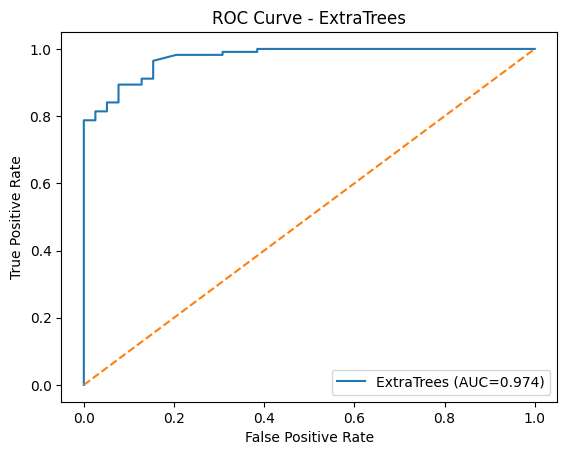

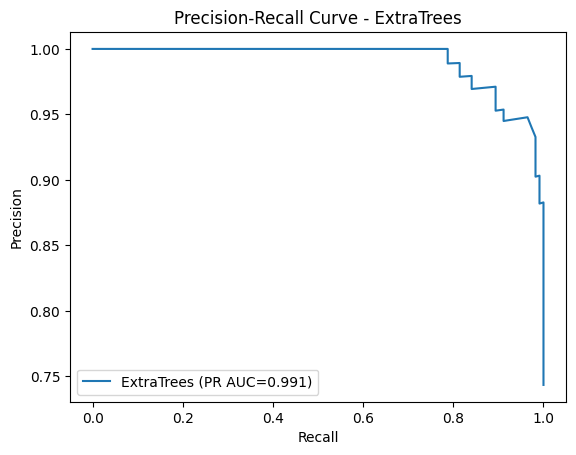


==================== DecisionTree ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.98      0.84      1000
           1       0.98      0.65      0.78      1000

    accuracy                           0.82      2000
   macro avg       0.86      0.82      0.81      2000
weighted avg       0.86      0.82      0.81      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.64      0.62        39
           1       0.87      0.85      0.86       113

    accuracy                           0.80       152
   macro avg       0.73      0.75      0.74       152
weighted avg       0.80      0.80      0.80       152

Training Time: 0.2708 sec
Inference Time: 0.003161 sec
Memory Usage (MB): 0.00
Cohen's Kappa: 0.4785
Brier Score: 0.2031
Confusion Matrix:
 [[25 14]
 [17 96]]


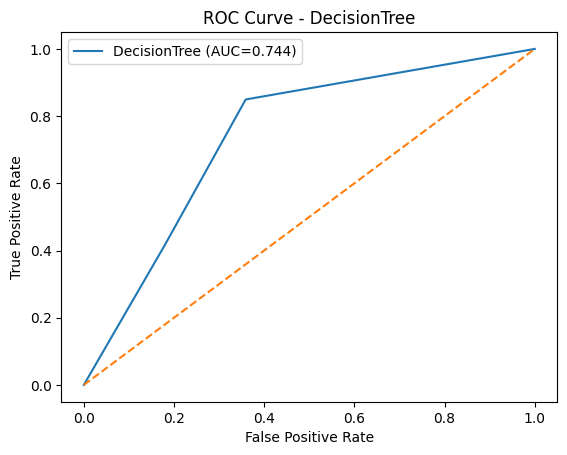

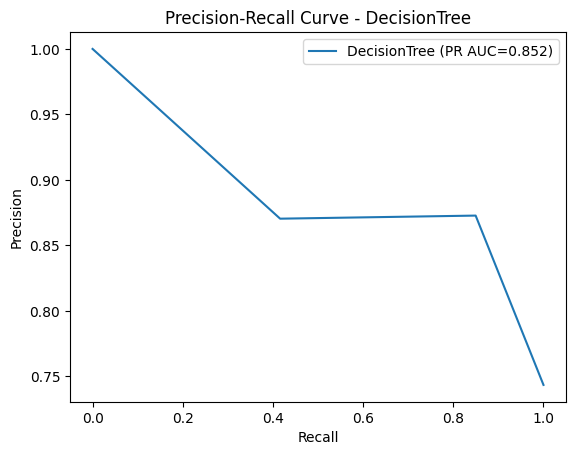


==================== XGBoost ====================


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:35:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.49      0.64        39
           1       0.85      0.99      0.91       113

    accuracy                           0.86       152
   macro avg       0.90      0.74      0.78       152
weighted avg       0.87      0.86      0.84       152

Training Time: 2.3800 sec
Inference Time: 0.012968 sec
Memory Usage (MB): 22.86
Cohen's Kappa: 0.5691
Brier Score: 0.0981
Confusion Matrix:
 [[ 19  20]
 [  1 112]]


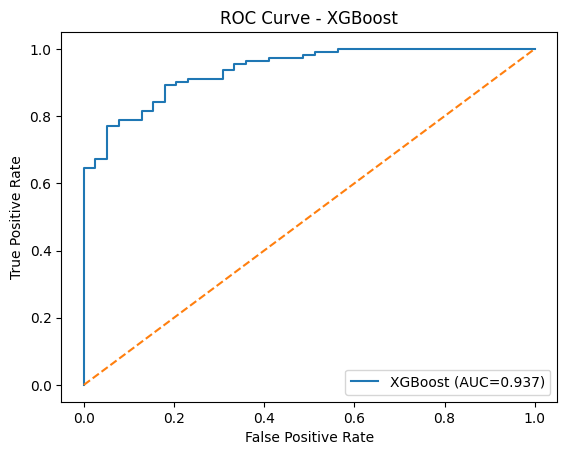

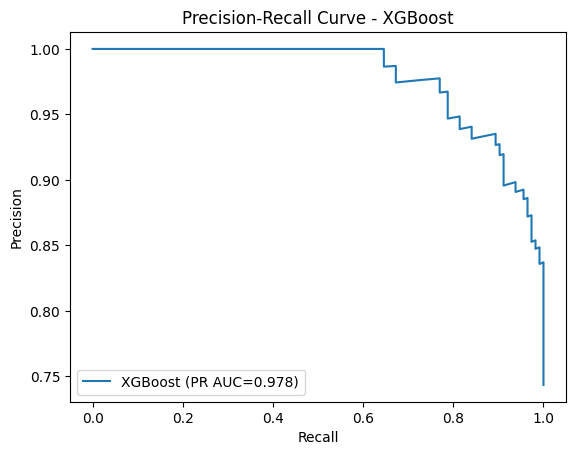


==================== CatBoost ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.28      0.43        39
           1       0.80      0.99      0.89       113

    accuracy                           0.81       152
   macro avg       0.86      0.64      0.66       152
weighted avg       0.83      0.81      0.77       152

Training Time: 28.6645 sec
Inference Time: 0.006747 sec
Memory Usage (MB): 8.99
Cohen's Kappa: 0.3533
Brier Score: 0.1257
Confusion Matrix:
 [[ 11  28]
 [  1 112]]


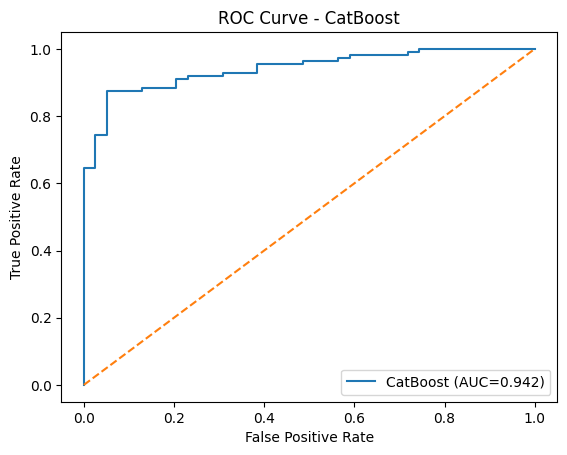

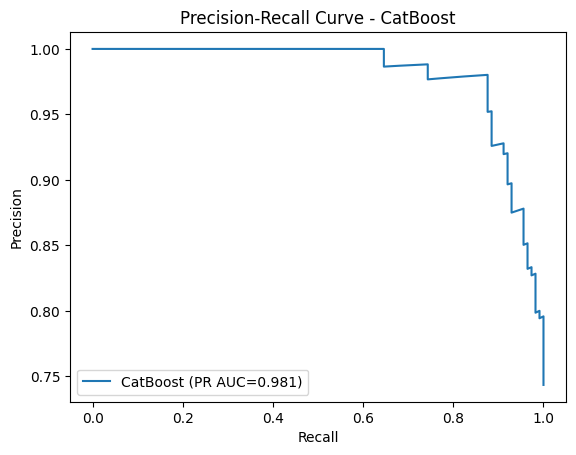

In [62]:
import time
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (classification_report, confusion_matrix, cohen_kappa_score,
                             brier_score_loss, roc_auc_score, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# =========================
# Data
# =========================
X_train = train_df.drop('class', axis=1)
y_train = train_df['class']
X_test = test_df.drop('class', axis=1)
y_test = test_df['class']

# =========================
# Models with best params
# =========================
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=10,
                                           min_samples_split=2, min_samples_leaf=1,
                                           max_features='log2', random_state=42),

    "ExtraTrees": ExtraTreesClassifier(n_estimators=100, max_depth=20,
                                       min_samples_split=5, min_samples_leaf=1,
                                       max_features='sqrt', random_state=42),

    "DecisionTree": DecisionTreeClassifier(max_depth=10, min_samples_split=2,
                                           min_samples_leaf=1, max_features=None,
                                           random_state=42),

    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                             min_child_weight=1, subsample=0.8, colsample_bytree=1.0,
                             use_label_encoder=False, eval_metric='logloss', random_state=42),

    "CatBoost": CatBoostClassifier(iterations=500, learning_rate=0.01, depth=10,
                                   l2_leaf_reg=1, border_count=64, verbose=0, random_state=42)
}

# =========================
# Evaluation Function
# =========================
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    print(f"\n{'='*20} {name} {'='*20}")

    # Memory before
    process = psutil.Process()
    mem_before = process.memory_info().rss / (1024 * 1024)

    # Training
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Memory after
    mem_after = process.memory_info().rss / (1024 * 1024)

    # Inference
    start_time = time.time()
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    infer_time = time.time() - start_time

    # Reports
    print("Train Classification Report:\n", classification_report(y_train, model.predict(X_train)))
    print("Test Classification Report:\n", classification_report(y_test, y_pred))

    # Metrics
    kappa = cohen_kappa_score(y_test, y_pred)
    brier = brier_score_loss(y_test, y_prob[:, 1]) if y_prob is not None and len(np.unique(y_test))==2 else None

    print(f"Training Time: {train_time:.4f} sec")
    print(f"Inference Time: {infer_time:.6f} sec")
    print(f"Memory Usage (MB): {mem_after - mem_before:.2f}")
    print(f"Cohen's Kappa: {kappa:.4f}")
    if brier is not None:
        print(f"Brier Score: {brier:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    # ROC AUC and Curve
    if y_prob is not None and len(np.unique(y_test))==2:
        roc_auc = roc_auc_score(y_test, y_prob[:, 1])
        fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
        plt.figure()
        plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')
        plt.plot([0,1],[0,1],'--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}")
        plt.legend()
        plt.show()

        # PR Curve
        precision, recall, _ = precision_recall_curve(y_test, y_prob[:, 1])
        pr_auc = average_precision_score(y_test, y_prob[:, 1])
        plt.figure()
        plt.plot(recall, precision, label=f'{name} (PR AUC={pr_auc:.3f})')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision-Recall Curve - {name}")
        plt.legend()
        plt.show()

# =========================
# Run Evaluation
# =========================
for name, model in models.items():
    evaluate_model(name, model, X_train, y_train, X_test, y_test)


In [63]:
import numpy as np
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score, average_precision_score
from sklearn.utils import resample

def bootstrap_ci(model, X_test, y_test, metric_func, n_bootstrap=1000, ci=95, seed=42):
    rng = np.random.RandomState(seed)
    scores = []

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    for i in range(n_bootstrap):
        indices = rng.randint(0, len(y_test), len(y_test))
        y_true_sample = y_test.iloc[indices] if hasattr(y_test, "iloc") else y_test[indices]
        y_pred_sample = y_pred[indices]
        y_prob_sample = y_prob[indices, :] if y_prob is not None else None

        if metric_func.__name__ in ["roc_auc_score", "average_precision_score"] and y_prob_sample is not None:
            score = metric_func(y_true_sample, y_prob_sample[:, 1])
        else:
            score = metric_func(y_true_sample, y_pred_sample)

        scores.append(score)

    lower = np.percentile(scores, (100-ci)/2)
    upper = np.percentile(scores, 100-(100-ci)/2)
    return np.mean(scores), lower, upper


In [64]:
model = models["RandomForest"]
model.fit(X_train, y_train)

acc_mean, acc_low, acc_high = bootstrap_ci(model, X_test, y_test, accuracy_score)
print(f"Accuracy: {acc_mean:.3f} [{acc_low:.3f}, {acc_high:.3f}]")

kappa_mean, kappa_low, kappa_high = bootstrap_ci(model, X_test, y_test, cohen_kappa_score)
print(f"Kappa: {kappa_mean:.3f} [{kappa_low:.3f}, {kappa_high:.3f}]")

roc_mean, roc_low, roc_high = bootstrap_ci(model, X_test, y_test, roc_auc_score)
print(f"ROC AUC: {roc_mean:.3f} [{roc_low:.3f}, {roc_high:.3f}]")

pr_mean, pr_low, pr_high = bootstrap_ci(model, X_test, y_test, average_precision_score)
print(f"PR AUC: {pr_mean:.3f} [{pr_low:.3f}, {pr_high:.3f}]")


Accuracy: 0.777 [0.711, 0.836]
Kappa: 0.181 [0.047, 0.323]
ROC AUC: 0.919 [0.865, 0.958]
PR AUC: 0.971 [0.947, 0.987]


In [65]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n===== {name} - 5-Fold Training Accuracy =====")

    fold_train_acc = []
    fold = 1

    for train_index, _ in skf.split(X_train, y_train):
        X_tr = X_train.iloc[train_index]
        y_tr = y_train.iloc[train_index]

        # Train
        model.fit(X_tr, y_tr)

        # Compute training accuracy on the same fold
        y_tr_pred = model.predict(X_tr)
        acc = accuracy_score(y_tr, y_tr_pred)
        fold_train_acc.append(acc)

        print(f"Fold {fold} Training Accuracy: {acc:.4f}")
        fold += 1

    mean_acc = np.mean(fold_train_acc)
    std_acc = np.std(fold_train_acc)
    print(f"Mean Training Accuracy: {mean_acc:.4f} | Std Dev: {std_acc:.4f}")



===== RandomForest - 5-Fold Training Accuracy =====
Fold 1 Training Accuracy: 0.8931
Fold 2 Training Accuracy: 0.8612
Fold 3 Training Accuracy: 0.9113
Fold 4 Training Accuracy: 0.8925
Fold 5 Training Accuracy: 0.8831
Mean Training Accuracy: 0.8882 | Std Dev: 0.0163

===== ExtraTrees - 5-Fold Training Accuracy =====
Fold 1 Training Accuracy: 0.7431
Fold 2 Training Accuracy: 0.7425
Fold 3 Training Accuracy: 0.7394
Fold 4 Training Accuracy: 0.7556
Fold 5 Training Accuracy: 0.7381
Mean Training Accuracy: 0.7438 | Std Dev: 0.0062

===== DecisionTree - 5-Fold Training Accuracy =====
Fold 1 Training Accuracy: 0.8431
Fold 2 Training Accuracy: 0.8294
Fold 3 Training Accuracy: 0.7956
Fold 4 Training Accuracy: 0.8525
Fold 5 Training Accuracy: 0.8431
Mean Training Accuracy: 0.8327 | Std Dev: 0.0200

===== XGBoost - 5-Fold Training Accuracy =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:36:07] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1 Training Accuracy: 1.0000


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:36:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2 Training Accuracy: 1.0000


...

Fold 3 Training Accuracy: 1.0000


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:36:14] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 4 Training Accuracy: 1.0000


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:36:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 5 Training Accuracy: 1.0000
Mean Training Accuracy: 1.0000 | Std Dev: 0.0000

===== CatBoost - 5-Fold Training Accuracy =====
Fold 1 Training Accuracy: 1.0000
Fold 2 Training Accuracy: 1.0000
Fold 3 Training Accuracy: 1.0000
Fold 4 Training Accuracy: 1.0000
Fold 5 Training Accuracy: 1.0000
Mean Training Accuracy: 1.0000 | Std Dev: 0.0000


**hybrid model**


==================== RandomForest ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       0.77      1.00      0.87      1000
           1       1.00      0.70      0.83      1000

    accuracy                           0.85      2000
   macro avg       0.89      0.85      0.85      2000
weighted avg       0.89      0.85      0.85      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.13      0.23        39
           1       0.77      1.00      0.87       113

    accuracy                           0.78       152
   macro avg       0.88      0.56      0.55       152
weighted avg       0.83      0.78      0.70       152

Training Time: 1.4491 sec
Inference Time: 0.021943 sec
Memory Usage (MB): 0.00
Cohen's Kappa: 0.1794
Brier Score: 0.1350
Confusion Matrix:
 [[  5  34]
 [  0 113]]


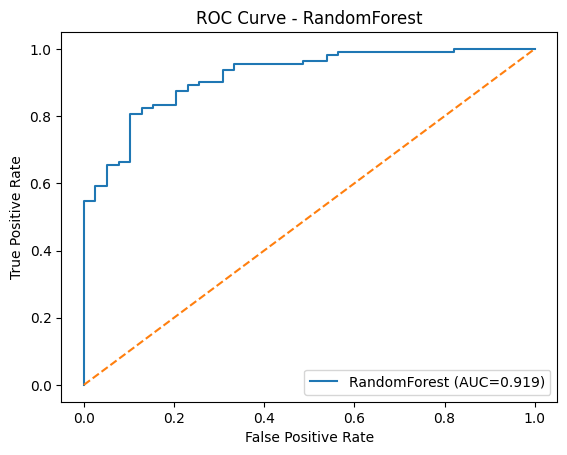

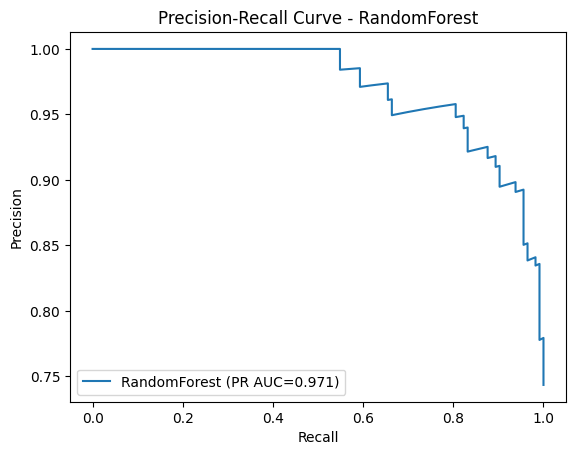


==================== ExtraTrees ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       0.65      1.00      0.79      1000
           1       1.00      0.47      0.64      1000

    accuracy                           0.74      2000
   macro avg       0.83      0.74      0.72      2000
weighted avg       0.83      0.74      0.72      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.10      0.19        39
           1       0.76      1.00      0.87       113

    accuracy                           0.77       152
   macro avg       0.88      0.55      0.53       152
weighted avg       0.82      0.77      0.69       152

Training Time: 0.3356 sec
Inference Time: 0.023326 sec
Memory Usage (MB): 0.00
Cohen's Kappa: 0.1452
Brier Score: 0.1242
Confusion Matrix:
 [[  4  35]
 [  0 113]]


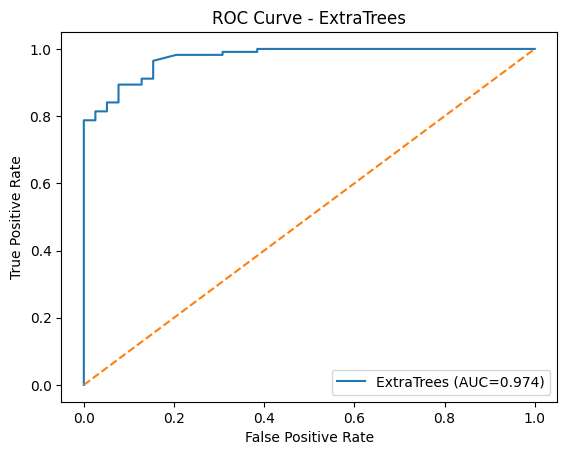

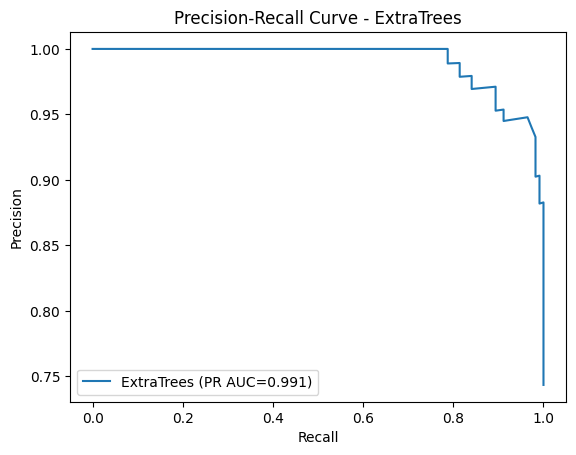


==================== DecisionTree ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.98      0.84      1000
           1       0.98      0.65      0.78      1000

    accuracy                           0.82      2000
   macro avg       0.86      0.82      0.81      2000
weighted avg       0.86      0.82      0.81      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.64      0.62        39
           1       0.87      0.85      0.86       113

    accuracy                           0.80       152
   macro avg       0.73      0.75      0.74       152
weighted avg       0.80      0.80      0.80       152

Training Time: 0.2612 sec
Inference Time: 0.003204 sec
Memory Usage (MB): 0.00
Cohen's Kappa: 0.4785
Brier Score: 0.2031
Confusion Matrix:
 [[25 14]
 [17 96]]


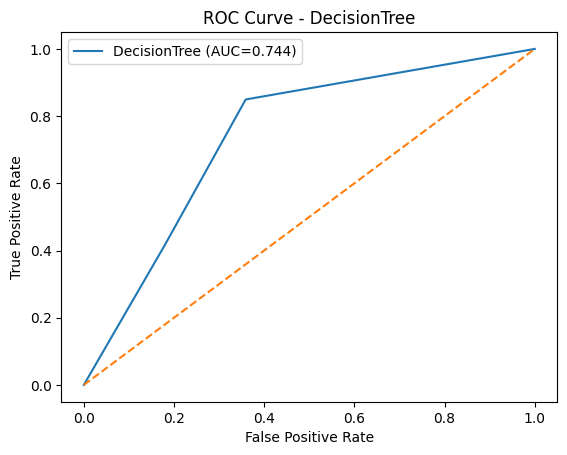

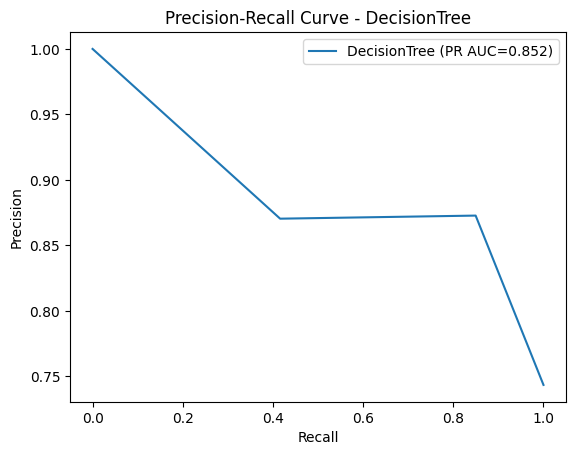


==================== XGBoost ====================


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:38:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.49      0.64        39
           1       0.85      0.99      0.91       113

    accuracy                           0.86       152
   macro avg       0.90      0.74      0.78       152
weighted avg       0.87      0.86      0.84       152

Training Time: 2.3129 sec
Inference Time: 0.010143 sec
Memory Usage (MB): 0.71
Cohen's Kappa: 0.5691
Brier Score: 0.0981
Confusion Matrix:
 [[ 19  20]
 [  1 112]]


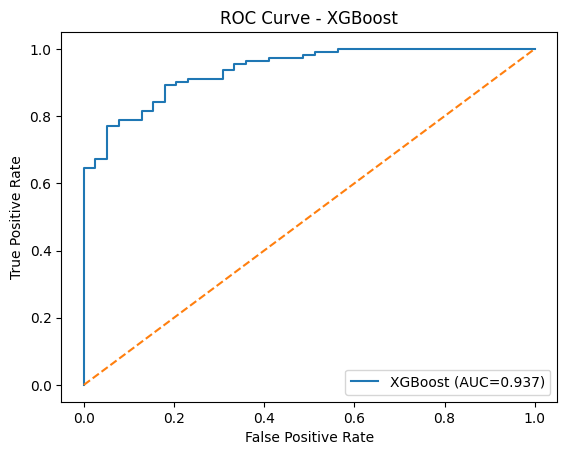

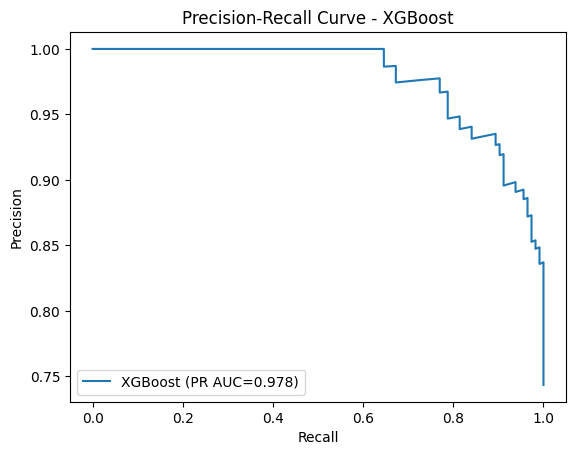


==================== CatBoost ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.28      0.43        39
           1       0.80      0.99      0.89       113

    accuracy                           0.81       152
   macro avg       0.86      0.64      0.66       152
weighted avg       0.83      0.81      0.77       152

Training Time: 29.7695 sec
Inference Time: 0.007903 sec
Memory Usage (MB): 4.22
Cohen's Kappa: 0.3533
Brier Score: 0.1257
Confusion Matrix:
 [[ 11  28]
 [  1 112]]


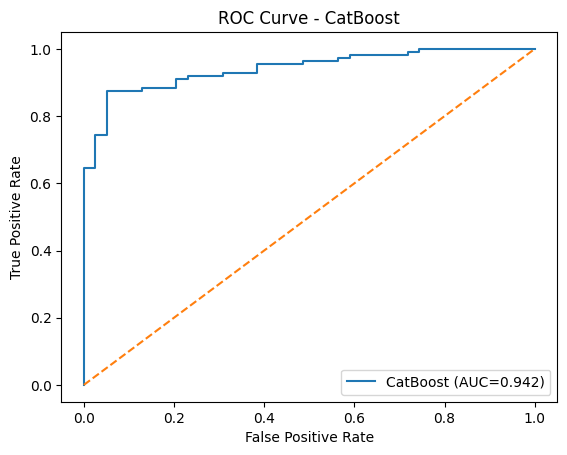

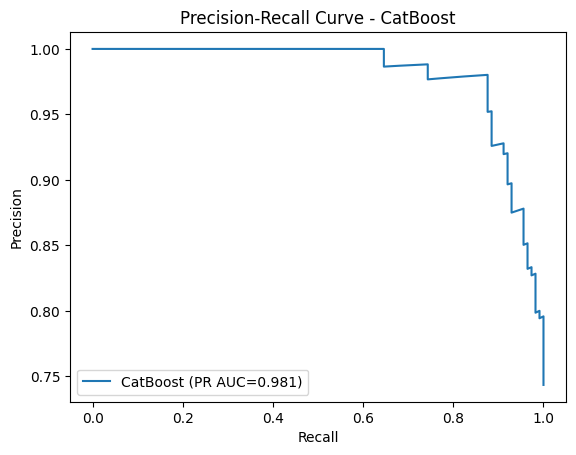


==================== HybridVoting ====================


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:39:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.31      0.47        39
           1       0.81      1.00      0.89       113

    accuracy                           0.82       152
   macro avg       0.90      0.65      0.68       152
weighted avg       0.86      0.82      0.78       152

Training Time: 32.2792 sec
Inference Time: 0.041775 sec
Memory Usage (MB): 20.96
Cohen's Kappa: 0.3979
Brier Score: 0.1127
Confusion Matrix:
 [[ 12  27]
 [  0 113]]


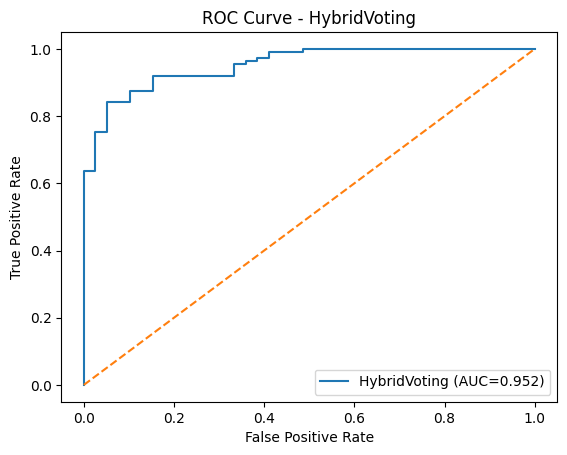

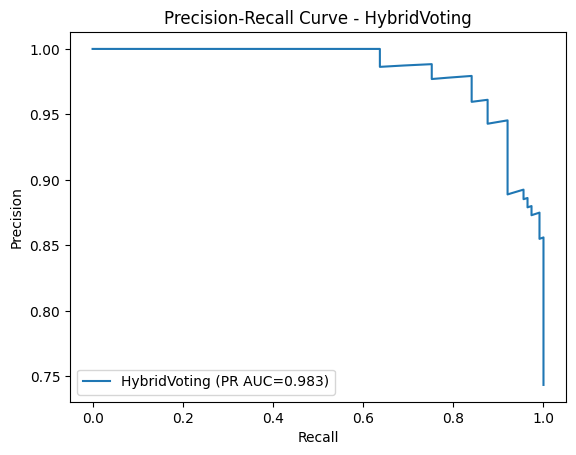

In [66]:
from sklearn.ensemble import VotingClassifier

# =========================
# Hybrid Voting Classifier
# =========================
voting_model = VotingClassifier(
    estimators=[
        ('rf', models['RandomForest']),
        ('xgb', models['XGBoost']),
        ('cat', models['CatBoost'])
    ],
    voting='soft'
)

models["HybridVoting"] = voting_model

# =========================
# Run Evaluation (including hybrid)
# =========================
for name, model in models.items():
    evaluate_model(name, model, X_train, y_train, X_test, y_test)


In [67]:
!pip install SALib


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:39:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Top 10 important features:
   feature  importance
0      PC1    0.582954
13    PC14    0.466238
9     PC10    0.333359
54    PC55    0.281564
4      PC5    0.203965
42    PC43    0.195283
57    PC58    0.186937
21    PC22    0.185566
64    PC65    0.178322
18    PC19    0.165579


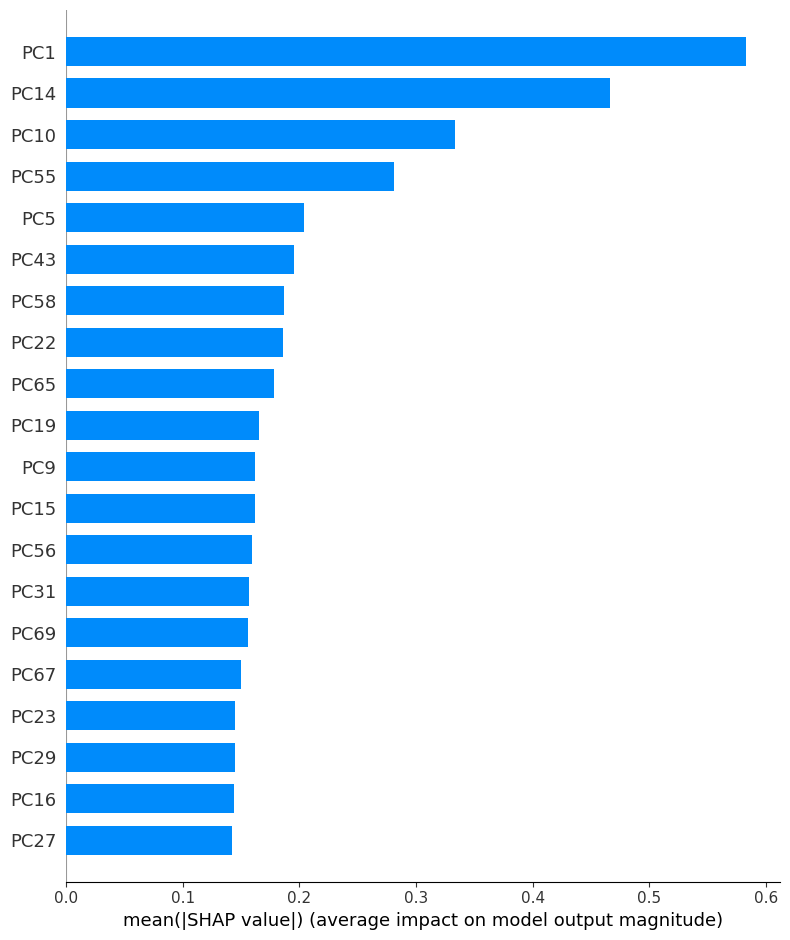

In [68]:
import shap


X = train_df.drop('class', axis=1)
y = train_df['class']


from xgboost import XGBClassifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X, y)


explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)


shap_importance = np.abs(shap_values).mean(axis=0)


feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': shap_importance
}).sort_values(by='importance', ascending=False)

print("Top 10 important features:")
print(feature_importance.head(10))


shap.summary_plot(shap_values, X, plot_type="bar")


In [69]:
pip install lime

In [70]:
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd


X = train_df.drop('class', axis=1)
y = train_df['class']


from xgboost import XGBClassifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X, y)


explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X.values,
    feature_names=X.columns,
    class_names=['Class 0', 'Class 1'],
    mode='classification'
)


sample_idx = [0, 1, 2]
for idx in sample_idx:
    sample = X.iloc[idx].values.reshape(1, -1)

    # Explain instance
    exp = explainer.explain_instance(
        data_row=sample[0],
        predict_fn=xgb_model.predict_proba,
        num_features=10
    )

    print(f"\nLIME explanation for sample {idx}:")
    exp.show_in_notebook(show_table=True, show_all=False)
    # Or print explanation in console
    print(exp.as_list())


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:40:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



LIME explanation for sample 0:


[('0.00 < PC14 <= 0.01', -0.09446373367976858), ('1.00 < PC1 <= 1.00', -0.07825467680312796), ('PC43 > 0.01', -0.04902115468111132), ('PC47 <= 0.99', 0.04517880032497344), ('PC71 > 0.06', -0.0375734927543087), ('PC52 > 1.00', 0.036192754880515765), ('PC56 <= 0.00', -0.03353941408356231), ('0.00 < PC6 <= 0.00', -0.03301824310662292), ('0.98 < PC68 <= 0.99', -0.03290112639041442), ('PC67 > 1.00', -0.032607528669638904)]

LIME explanation for sample 1:


[('PC14 <= 0.00', -0.11272017399397824), ('PC10 > 1.00', -0.11059263188145774), ('PC1 <= 0.99', -0.10670310450019148), ('PC27 <= 0.98', -0.08052175402958682), ('PC55 > 1.00', -0.06866475857583942), ('PC5 <= 0.19', 0.05783386307123614), ('PC41 <= 0.00', 0.05776531046518622), ('PC19 <= 0.69', 0.05385053497005507), ('PC67 > 1.00', -0.04963320322127455), ('PC22 <= 0.00', 0.04851842660207803)]

LIME explanation for sample 2:


[('PC1 <= 0.99', -0.12329563843445894), ('PC22 > 0.01', -0.06947761415600252), ('PC29 <= 0.99', -0.0634011059990997), ('PC46 <= 0.98', 0.048776696421309135), ('PC27 <= 0.98', -0.0401411245175834), ('PC48 > 0.01', 0.03885947823626944), ('PC43 > 0.01', -0.03864267794321624), ('0.99 < PC55 <= 1.00', -0.036201871323014695), ('0.38 < PC5 <= 0.53', -0.03483053356563257), ('0.00 < PC34 <= 0.01', -0.03190779033239244)]
